# Grammaires probabilistes et parsing CYK — de la CFG a la derivation la plus probable

**Navigation** : [<< Precedent — 23. TAL, du mot aux dependances](23_TAL_Du_Mot_Aux_Dependances.ipynb) | [Index de la serie Texte](README.md) | **26 (ce notebook)**

**Sommaire** : [1. CFG explicite](#1-une-grammaire-a-contexte-libre-explicite) · [2. Productions et CNF](#2-productions-completes-et-forme-normale-de-chomsky) · [3. Recognizer CYK](#3-le-recognizer-cyk-programmation-dynamique-en-table-triangulaire) · [4. PCFG et treebank](#4-la-pcfg-estimer-les-probabilites-sur-un-mini-treebank) · [5. Viterbi et inside](#5-viterbi-et-inside-la-meilleure-derivation-nest-pas-la-phrase) · [6. Ambiguïté mesuree](#6-ambiguïté-mesuree-compter-les-derivations-et-peser-les-lectures) · [7. Témoin NLTK](#7-témoin-nltk-verifier-notre-parseur-contre-la-reference) · [8. Exercices](#8-exercices) · [Conclusion](#conclusion)

La serie Texte traite le langage **cote modele** : prompts, RAG, fine-tuning. Le notebook [`23_TAL_Du_Mot_Aux_Dependances.ipynb`](23_TAL_Du_Mot_Aux_Dependances.ipynb) a execute la seconde tradition — le **TAL classique** — au niveau du *mot* : lemmes, etiquettes morphosyntaxiques, dependances, entites nommees. Il manquait l'etage au-dessus : la **structure syntaxique** d'une phrase entiere.

C'est le role d'une **grammaire a contexte libre** (CFG) : un ensemble de regles de reecriture `S -> NP VP` qui decompose recursivement une phrase en constituants. Une CFG repond *oui* ou *non* a la question « cette phrase est-elle grammaticale ? ». Une **PCFG** — sa version ponderee par des probabilites — repond a la question plus fine : « *quelle* analyse syntaxique est la plus probable ? », ce qui importe des qu'une phrase est **ambigue**.

Ce notebook construit tout cela **from scratch**, sur un mini-francais fil rouge (un robot, un ballon, une boite) :

1. une CFG explicite, convertie en **forme normale de Chomsky (CNF)** par un convertisseur documente qui **preserve les probabilites** ;
2. le **recognizer CYK** — programmation dynamique en table triangulaire — visualise cellule par cellule ;
3. l'estimation des probabilites de regles par **maximum de vraisemblance** sur un mini-treebank construit et explique ici meme ;
4. le decodage **Viterbi** de la meilleure derivation, avec backpointers et reconstruction de l'arbre dans la grammaire d'origine ;
5. l'**ambiguïté mesuree** : nombre de derivations, probabilites comparees, et la distinction nette entre *meilleure derivation* et *probabilite totale de la phrase* (somme de toutes les derivations, algorithme inside) ;
6. un **temoin** : le meme calcul refait par `nltk`, la bibliotheque de reference, pour verifier que notre implementation donne *exactement* les memes nombres.

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. **Ecrire** une CFG et la convertir en CNF en preservant les probabilites ;
2. **Implementer** CYK (table triangulaire, complexite O(n^3 |G|)) et lire sa table ;
3. **Estimer** une PCFG par maximum de vraisemblance sur un treebank et mesurer son biais ;
4. **Decoder** la derivation la plus probable (Viterbi + backpointers) et la distinguer de la probabilite totale (inside) ;
5. **Verifier** une implementation de parseur contre un temoin de reference (`nltk`).

### Prerequis

- Python 3.10+, `matplotlib`, `pandas`, `nltk` (CPU uniquement, aucun telechargement de corpus NLTK requis) ;
- notions du notebook [`23_TAL_Du_Mot_Aux_Dependances.ipynb`](23_TAL_Du_Mot_Aux_Dependances.ipynb) (categories Det/N/V/P) recommandees.

### Duree estimee : 55 minutes


## 1. Une grammaire a contexte libre explicite

Une **CFG** est un quadruplet : non-terminaux `N` (`S`, `NP`, `VP`, `PP`, `Det`, `N`, `V`, `P`), terminaux `T` (les mots), un axiome `S`, et des **regles de production** `A -> alpha` ou `A` est un non-terminal et `alpha` une sequence de symboles. Le « contexte libre » signifie que la recriture d'un non-terminal ne depend **pas** de son entourage — c'est ce qui rend le parsing polynomial possible.

Notre mini-francais : sept regles syntaxiques (phrase, groupe nominal avec ou sans complement prepositionnel, groupe verbal intransitif / transitif / transitif+complement, groupe prepositionnel) et un lexique borne de quatre categories. Les deux regles `NP -> Det N PP` et `VP -> V NP PP` coexistent : c'est ce qui rendra la phrase fil rouge **ambigue** (le complement prepositionnel peut s'attacher au nom ou au verbe).


In [1]:
import itertools
import math
from collections import Counter, defaultdict
from fractions import Fraction

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline


REGLES = [
    ("S",  ("NP", "VP")),          # phrase = syntagme nominal + verbal
    ("NP", ("Det", "N")),          # groupe nominal simple
    ("NP", ("Det", "N", "PP")),    # groupe nominal avec complement
    ("VP", ("V",)),                # unite : verbe intransitif
    ("VP", ("V", "NP")),           # groupe verbal transitif
    ("VP", ("V", "NP", "PP")),     # groupe verbal + complement
    ("PP", ("P", "NP")),           # groupe prepositionnel
]
LEXIQUE = {
    "Det": ["le", "la", "un", "une"],
    "N":   ["robot", "ballon", "boite", "camembert", "couteau", "table"],
    "V":   ["voit", "mange", "trouve", "coupe", "dort"],
    "P":   ["dans", "sur", "avec"],
}
AXIOME = "S"

print("Regles syntaxiques :", len(REGLES))
for lhs, rhs in REGLES:
    print(f"  {lhs:3s} -> {' '.join(rhs)}")
n_lex = sum(len(mots) for mots in LEXIQUE.values())
print(f"Regles lexicales   : {n_lex}")
for cat, mots in LEXIQUE.items():
    print(f"  {cat:3s} -> {' | '.join(mots)}")
print(f"Total productions  : {len(REGLES) + n_lex}")


Regles syntaxiques : 7
  S   -> NP VP
  NP  -> Det N
  NP  -> Det N PP
  VP  -> V
  VP  -> V NP
  VP  -> V NP PP
  PP  -> P NP
Regles lexicales   : 18
  Det -> le | la | un | une
  N   -> robot | ballon | boite | camembert | couteau | table
  V   -> voit | mange | trouve | coupe | dort
  P   -> dans | sur | avec
Total productions  : 25


### Lecture du resultat

La grammaire declare **7 regles syntaxiques** et **18 regles lexicales** (4 determinants + 6 noms + 5 verbes + 3 prepositions), soit **25 productions**. La grammaire accepte des phrases de longueur arbitraire (les complements prepositionnels peuvent s'empiler), mais notre jeu de test les borne a trois a huit mots ; surtout, elle autorise les deux formes « avec PP » : `NP -> Det N PP` (le complement se rattache au *nom*) et `VP -> V NP PP` (le complement se rattache au *verbe*).

**Point cle** : cette grammaire reste volontairement minuscule. Tout ce qui suit — table CYK, probabilites, Viterbi — sera *lisible* precisement parce que chaque regle et chaque cellule de table tient dans l'ecran.


## 2. Productions completes et forme normale de Chomsky

CYK exige une grammaire en **forme normale de Chomsky** : chaque regle est soit `A -> B C` (deux non-terminaux), soit `A -> w` (un seul mot). Notre grammaire viole les deux formes : `VP -> V NP PP` a **trois** fils, `VP -> V` est une **regle unitaire** (un non-terminal seul), et aucun terminal n'apparait dans un rhs long ici mais le convertisseur doit savoir les traiter.

Le convertisseur `vers_cnf` applique trois transformations **bornees** (chacune n'augmente la grammaire que d'un facteur constant sur notre cas) :

| Transformation | Regle d'origine | Regles CNF produites | Probabilite |
|---|---|---|---|
| **Terminal dans un rhs long** | `A -> B w` | `A -> B TERM_w`, `TERM_w -> w` | `p` garde par `A`, `TERM_w -> w` a 1 |
| **Binarisation** | `A -> B C D` | `A -> B A_1`, `A_1 -> C D` | `p` sur la tete, 1 sur la suite |
| **Unite** | `A -> B` | `A -> (toutes les regles de B)` | `p(A->B) * p(B->...)` |

La **provenance** de chaque regle CNF est enregistree : c'est ce qui permettra, en section 5, de replier un arbre CNF vers l'arbre de la grammaire d'origine sans perdre aucune information.


In [2]:
def productions(regles, lexique):
    """Liste complete des productions : syntaxe + lexique."""
    prods = list(regles)
    for cat, mots in lexique.items():
        for m in mots:
            prods.append((cat, (m,)))
    return prods

PRODUCTIONS = productions(REGLES, LEXIQUE)
print(f"{len(PRODUCTIONS)} productions au total ({len(REGLES)} syntaxiques + {n_lex} lexicales)")

def vers_cnf(productions, probas=None):
    """Convertit une liste de productions (lhs, rhs) vers la CNF.

    Trois transformations, chacune bornee :
    1. terminal dans un rhs de longueur >= 2 -> preterminal TERM_x (p=1) ;
    2. rhs de longueur >= 3 -> binarisation avec marqueurs lhs_1, lhs_2...
       (la tete garde la probabilite d'origine, la suite porte p=1) ;
    3. unite A -> B remplacee par A -> (regles de B), probabilite
       multipliee le long de la chaine.
    Retourne (regles_cnf, probas_cnf, provenance).
    """
    if probas is None:
        probas = {}
    def p(regle):
        return probas.get(regle, 1.0)
    nt = {lhs for lhs, _ in productions}

    prov = {}
    p_cnf = {}

    # --- 1. isoler les terminaux des rhs longs
    etape1 = []
    for lhs, rhs in productions:
        if len(rhs) >= 2 and any(x not in nt for x in rhs):
            nouvelle = []
            for x in rhs:
                if x in nt:
                    nouvelle.append(x)
                else:
                    pt = f"TERM_{x}"
                    regle_pt = (pt, (x,))
                    if regle_pt not in etape1:
                        etape1.append(regle_pt)
                        prov[regle_pt] = ("terminal_isole", x)
                        p_cnf[regle_pt] = 1.0
                    nouvelle.append(pt)
            etape1.append((lhs, tuple(nouvelle)))
            prov[(lhs, tuple(nouvelle))] = ("identique", rhs)
            p_cnf[(lhs, tuple(nouvelle))] = p((lhs, rhs))
        else:
            etape1.append((lhs, rhs))
            prov[(lhs, rhs)] = ("identique", rhs)
            p_cnf[(lhs, rhs)] = p((lhs, rhs))

    # --- 2. binariser les rhs de longueur >= 3
    etape2 = []
    for lhs, rhs in etape1:
        if len(rhs) <= 2:
            etape2.append((lhs, rhs))
        else:
            reste, parent, i = rhs, lhs, 1
            while len(reste) > 2:
                marqueur = f"{lhs}_{i}"
                etape2.append((parent, (reste[0], marqueur)))
                prov[(parent, (reste[0], marqueur))] = ("binarisation", rhs)
                p_cnf[(parent, (reste[0], marqueur))] = p((lhs, rhs)) if parent == lhs else 1.0
                reste = reste[1:]
                parent = marqueur
                i += 1
            etape2.append((parent, reste))
            prov[(parent, reste)] = ("suite_binarisee", rhs)
            p_cnf[(parent, reste)] = 1.0

    # --- 3. eliminer les unites (rhs = un seul non-terminal)
    unites = [(l, r[0]) for l, r in etape2 if len(r) == 1 and r[0] in nt]
    non_unites = [(l, r) for l, r in etape2 if not (len(r) == 1 and r[0] in nt)]
    p_non_unites = {r: p_cnf[r] for r in non_unites}
    p_unite = {(l, (b,)): p_cnf.get((l, (b,)), p((l, (b,)))) for l, b in unites}

    finales = list(non_unites)
    p_finales = dict(p_non_unites)
    for l, b in unites:
        for regle_b, pb in p_non_unites.items():
            if regle_b[0] == b:
                nouvelle = (l, regle_b[1])
                finales.append(nouvelle)
                p_finales[nouvelle] = p_unite[(l, (b,))] * pb
                prov[nouvelle] = ("unite", [(l, (b,)), regle_b])
    return finales, p_finales, prov

CNF_STRUCTURELLE, _, _ = vers_cnf(PRODUCTIONS)

def est_cnf(regles):
    """True ssi toute regle est A -> B C (deux non-terminaux) ou A -> w."""
    nt = {lhs for lhs, _ in regles}
    for lhs, rhs in regles:
        if len(rhs) == 2 and all(x in nt for x in rhs):
            continue
        if len(rhs) == 1 and rhs[0] not in nt:
            continue
        return False
    return True

print(f"{len(PRODUCTIONS)} productions -> {len(CNF_STRUCTURELLE)} regles CNF")
print("Propriete CNF verifiee :", est_cnf(CNF_STRUCTURELLE))
print("\nNouvelles regles introduites par la conversion :")
initiales = set(PRODUCTIONS)
for r in CNF_STRUCTURELLE:
    if r not in initiales:
        lhs, rhs = r
        print(f"  {lhs:5s} -> {' '.join(rhs)}")


25 productions au total (7 syntaxiques + 18 lexicales)
25 productions -> 31 regles CNF
Propriete CNF verifiee : True

Nouvelles regles introduites par la conversion :
  NP    -> Det NP_1
  NP_1  -> N PP
  VP    -> V VP_1
  VP_1  -> NP PP
  VP    -> voit
  VP    -> mange
  VP    -> trouve
  VP    -> coupe
  VP    -> dort


### Lecture du resultat

Les 25 productions deviennent **31 regles CNF** : la verification `est_cnf` confirme que chaque regle est bien `A -> B C` ou `A -> w`. La conversion a introduit neuf regles nouvelles :

- **deux marqueurs de binarisation** : `NP_1 -> N PP` (suite de `NP -> Det N PP`) et `VP_1 -> NP PP` (suite de `VP -> V NP PP`), avec leurs tetes `NP -> Det NP_1` et `VP -> V VP_1` ;
- **cinq regles issues de l'unite** `VP -> V` : le verbe intransitif « remonte » comme production directe de `VP` (`VP -> voit`, `VP -> mange`, ...), ce qui permettra a un `V` seul d'etre immediatement un `VP` ;
- aucun preterminal `TERM_x` : notre grammaire ne place jamais un mot dans un rhs long, la transformation 1 reste disponible mais inutilisee ici.

**Point cle** : la conversion est *structurale* pour l'instant (toutes les probabilites valent 1 par defaut). Nous la referons en section 4 avec les probabilites estimees, et nous **verifierons alors explicitement** que la distribution est preservee.


## 3. Le recognizer CYK — programmation dynamique en table triangulaire

CYK (Cocke-Younger-Kasami) repond a la question d'appartenance : « la phrase est-elle dans le langage de la grammaire ? ». L'idee est la **programmation dynamique sur les sous-chaines** : on remplit une table triangulaire `chart[i][l]` = ensemble des non-terminaux qui derivent les mots de la position `i` a `i+l`.

- **Base** (`l = 1`) : un mot `w` est derive par tous les non-terminaux qui ont la regle lexicale `A -> w` ;
- **Recurrence** (`l >= 2`) : pour chaque **point de coupure** `k`, si `B` derive `phrase[i:i+k]` et `C` derive `phrase[i+k:i+l]`, alors tout `A -> B C` derive `phrase[i:i+l]` ;
- **Verdict** : la phrase est acceptee si l'axiome `S` est dans `chart[0][n]` (la cellule au sommet, qui couvre toute la phrase).

La complexite est `O(n^3 * |G|)` — cubique dans la longueur de la phrase, lineaire dans la taille de la grammaire — et c'est **exactement** pour cette forme de recurrence a deux coupures que la CNF est necessaire.

On l'execute sur cinq phrases : deux **positives** (`P1` intransitive, `P2` transitive), une **ambigue** (`AMB`, huit mots, qui donnera deux analyses en section 5), et deux **negatives** pour des raisons differentes — `N1` s'arrete sur un determinant seul : le dernier mot `le` ouvre un groupe nominal que la phrase ne complete pas et `N2` contient un mot **hors lexique**.


In [3]:
def table_cyk(regles_cnf, phrase, axiome="S"):
    """Table triangulaire CYK : chart[i][l] = NT derivant phrase[i:i+l]."""
    jetons = phrase.split()
    n = len(jetons)
    chart = [[set() for _ in range(n + 1)] for _ in range(n)]
    for i, w in enumerate(jetons):
        for lhs, rhs in regles_cnf:
            if rhs == (w,):
                chart[i][1].add(lhs)
    for l in range(2, n + 1):
        for i in range(n - l + 1):
            for k in range(1, l):
                for lhs, rhs in regles_cnf:
                    if len(rhs) == 2 and rhs[0] in chart[i][k] and rhs[1] in chart[i + k][l - k]:
                        chart[i][l].add(lhs)
    return chart

def reconnait(regles_cnf, phrase, axiome="S"):
    jetons = phrase.split()
    chart = table_cyk(regles_cnf, phrase)
    return axiome in chart[0][len(jetons)], chart

def affiche_chart(chart, phrase, titre=""):
    """Chart CYK en DataFrame triangulaire (ligne = longueur, colonne = debut)."""
    jetons = phrase.split()
    n = len(jetons)
    lignes = {}
    for l in range(n, 0, -1):
        ligne = {}
        for i in range(n):
            if i + l <= n:
                ligne[f"{i}:{jetons[i]}"] = ", ".join(sorted(chart[i][l])) or "-"
        lignes[f"l={l}"] = ligne
    return pd.DataFrame(lignes)

PHRASES = {
    "P1":  "le robot dort",
    "P2":  "le robot voit le ballon",
    "AMB": "le robot voit le ballon dans la boite",
    "N1":  "le robot voit le",
    "N2":  "le zorglub voit le ballon",
}
print("Reconnaissance CYK (grammaire structurelle, sans probabilites) :")
for nom, ph in PHRASES.items():
    ok, _ = reconnait(CNF_STRUCTURELLE, ph)
    verdict = "ACCEPTEE" if ok else "REJETEE "
    print(f"  {nom:3s} {ph!r:45s} -> {verdict}")


Reconnaissance CYK (grammaire structurelle, sans probabilites) :
  P1  'le robot dort'                               -> ACCEPTEE
  P2  'le robot voit le ballon'                     -> ACCEPTEE
  AMB 'le robot voit le ballon dans la boite'       -> ACCEPTEE
  N1  'le robot voit le'                            -> REJETEE 
  N2  'le zorglub voit le ballon'                   -> REJETEE 


### Lecture du resultat

Les verdicts sont ceux attendus : `P1`, `P2` et `AMB` sont **acceptees**, `N1` et `N2` sont **rejetees**. Remarquez que le recognizer ne distingue pas encore les deux negations : les deux se soldent par une cellule sommet vide. La section suivante ouvre la table pour *comprendre* les rejets, puis visualise la phrase ambigue.


### Ouvrir la table : la phrase ambigue

La table triangulaire de `AMB` (« le robot voit le ballon dans la boite », huit mots) se lit **de bas en haut** : la ligne `l=1` sont les mots, chaque ligne montante couvre des fragments de plus en plus longs, et la cellule sommet `l=8` — qui contient `S` — certifie l'acceptation. Deux representations : le `DataFrame` textuel, puis la grille colorée.


          l=8  l=7  l=6       l=5   l=4  l=3  l=2    l=1
0:le        S    -    -         S     -    S   NP    Det
1:robot   NaN    -    -         -     -    -    -      N
2:voit    NaN  NaN   VP         -     -   VP    -  V, VP
3:le      NaN  NaN  NaN  NP, VP_1     -    -   NP    Det
4:ballon  NaN  NaN  NaN       NaN  NP_1    -    -      N
5:dans    NaN  NaN  NaN       NaN   NaN   PP    -      P
6:la      NaN  NaN  NaN       NaN   NaN  NaN   NP    Det
7:boite   NaN  NaN  NaN       NaN   NaN  NaN  NaN      N


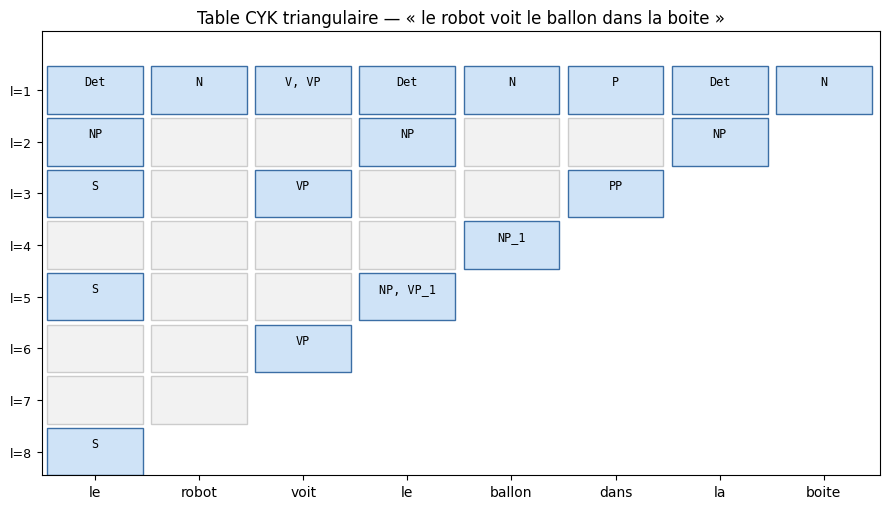

In [4]:
chart_amb = table_cyk(CNF_STRUCTURELLE, PHRASES["AMB"])
df = affiche_chart(chart_amb, PHRASES["AMB"])
print(df.to_string())

jetons = PHRASES["AMB"].split()
n = len(jetons)
fig, ax = plt.subplots(figsize=(9, 5.2))
for l in range(1, n + 1):
    for i in range(n - l + 1):
        contenu = ", ".join(sorted(chart_amb[i][l]))
        if contenu:
            ax.add_patch(plt.Rectangle((i, n - l), 0.92, 0.92,
                                       facecolor="#cfe3f7", edgecolor="#3b6ea5"))
            ax.text(i + 0.46, n - l + 0.62, contenu, ha="center", va="center",
                    fontsize=8.5, family="monospace")
        else:
            ax.add_patch(plt.Rectangle((i, n - l), 0.92, 0.92,
                                       facecolor="#f2f2f2", edgecolor="#cccccc"))
ax.set_xlim(-0.05, n)
ax.set_ylim(0, n + 0.6)
ax.set_xticks([j + 0.46 for j in range(n)])
ax.set_xticklabels(jetons, fontsize=10)
ax.set_yticks([n - l + 0.46 for l in range(1, n + 1)])
ax.set_yticklabels([f"l={l}" for l in range(1, n + 1)], fontsize=9)
ax.set_title("Table CYK triangulaire — « le robot voit le ballon dans la boite »")
plt.tight_layout()
plt.show()
plt.close("all")


### Lecture du resultat

La grille montre la dynamique de bas en haut. Trois cellules portent le sens de l'ambiguïté :

- la cellule `(0, 8)` — toute la phrase — contient `S` : la phrase est bien dans le langage ;
- la cellule `(3, 5)` — « le ballon dans la boite » — contient **a la fois** `NP` *et* `VP_1` : le meme fragment de cinq mots peut etre un groupe nominal complet (attachement **nominal**) ou la suite binarisee d'un groupe verbal (attachement **verbal**) — c'est ici, materiellement, que vivent les deux lectures ;
- la cellule `(2, 6)` — « voit le ballon dans la boite » — contient `VP` : le groupe verbal transitif+complement est bien forme.

**Point cle** : CYK *reconnait* ; il ne dit pas encore **combien** d'analyses existent ni laquelle est preferable. C'est l'affaire des probabilites — sections 4 et 5.


### Pourquoi les phrases negatives sont-elles rejetees ?

Un « non » de CYK est muet ; la table, elle, se souvient de *ou* ca a coince. On inspecte deux indices : les mots sans categorie a la ligne `l=1`, et le contenu de la cellule sommet.


In [5]:
for nom in ["N1", "N2"]:
    ph = PHRASES[nom]
    ok, chart = reconnait(CNF_STRUCTURELLE, ph)
    jetons_n = ph.split()
    n_n = len(jetons_n)
    # derniere cellule (0, n)
    cellule_finale = ", ".join(sorted(chart[0][n_n])) or "(vide)"
    # premiere ligne : mots hors lexique
    hors_lexique = [w for i, w in enumerate(jetons_n) if not chart[i][1]]
    print(f"{nom} {ph!r}")
    print(f"  mots hors lexique : {hors_lexique if hors_lexique else 'aucun'}")
    print(f"  cellule (0, n={n_n}) = {{{cellule_finale}}}")
    print(f"  verdict : {'ACCEPTEE' if ok else 'REJETEE'}")
    print()


N1 'le robot voit le'
  mots hors lexique : aucun
  cellule (0, n=4) = {(vide)}
  verdict : REJETEE

N2 'le zorglub voit le ballon'
  mots hors lexique : ['zorglub']
  cellule (0, n=5) = {(vide)}
  verdict : REJETEE



### Lecture du resultat

Les deux rejets ont des causes distinctes, visibles dans la table :

| Cas | Indice dans la table | Cause |
|---|---|---|
| `N1` « le robot voit le » | aucun mot hors lexique, cellule sommet vide | **structurelle** : le determinant final `le` ouvre un groupe nominal qui reste inacheve — aucun `NP` ne couvre la fin de phrase, donc la cellule sommet reste vide |
| `N2` « le zorglub voit le ballon » | `zorglub` n'a **aucune** categorie a `l=1` | **lexicale** : le mot est hors vocabulaire, toute derivation est bloquee des la base |

**Point cle** : ces deux echecs reviendront en section 7 — NLTK rejette `N2` par une **exception** documentee, la ou notre recognizer repond simplement « non » : deux conventions d'API pour le meme fait linguistique.


## 4. La PCFG : estimer les probabilites sur un mini-treebank

Une **PCFG** est une CFG dont chaque regle `A -> alpha` porte une probabilite, avec pour chaque non-terminal `A` : la somme sur toutes ses regles vaut 1. La probabilite d'une **derivation** est le produit des probabilites des regles qu'elle utilise ; la probabilite d'une **phrase** est la somme sur toutes ses derivations.

D'ou viennent ces nombres ? D'un **treebank** : un corpus de phrases **deja analysees** (des arbres), dont on compte les regles. L'estimation est le **maximum de vraisemblance** : `P(A -> alpha) = #(A -> alpha) / #(A)`.

Notre treebank est **embarque** : six arbres ecrits a la main dans le notebook (notation parenthesee de type Penn Treebank), tous dans le mini-francais de la section 1. Il est volontairement petit — chaque comptage reste verifiable a l'oeil — et volontairement **biaise** : cinq phrases transitives contre une intransitive, un seul attachement nominal. Ce biais n'est pas un defaut : il *pilote* la desambiguïsation de la section 5, et nous le mesurerons.


In [6]:
TREEBANK = [
    "(S (NP (Det le) (N robot)) (VP (V voit) (NP (Det le) (N ballon))))",
    "(S (NP (Det le) (N robot)) (VP (V mange) (NP (Det le) (N camembert))))",
    "(S (NP (Det un) (N robot)) (VP (V trouve) (NP (Det un) (N ballon)) (PP (P dans) (NP (Det la) (N boite)))))",
    "(S (NP (Det la) (N boite)) (VP (V coupe) (NP (Det le) (N camembert)) (PP (P avec) (NP (Det le) (N couteau)))))",
    "(S (NP (Det le) (N robot)) (VP (V voit) (NP (Det le) (N ballon) (PP (P sur) (NP (Det la) (N table))))))",
    "(S (NP (Det le) (N robot)) (VP (V dort)))",
]

def parse_sexpr(s):
    """S-expression '(A (B b) ...)' -> ('A', [('B', [('b', [])]), ...])."""
    jetons = s.replace("(", " ( ").replace(")", " ) ").split()
    pos = 0
    def lit():
        nonlocal pos
        pos += 1                      # '('
        label = jetons[pos]; pos += 1
        enfants = []
        while jetons[pos] != ")":
            if jetons[pos] == "(":
                enfants.append(lit())
            else:
                enfants.append((jetons[pos], []))
                pos += 1
        pos += 1                      # ')'
        return (label, enfants)
    arbre = lit()
    assert pos == len(jetons)
    return arbre

def regles_de_larbre(arbre, accumulateur):
    """Collecte les productions (pere, (enfants...)) d'un arbre recursivement."""
    label, enfants = arbre
    rhs = []
    for e in enfants:
        regles_de_larbre(e, accumulateur)
        rhs.append(e[0])
    accumulateur.append((label, tuple(rhs)))

comptes = Counter()
for phrase_arbre in TREEBANK:
    regles_vues = []
    regles_de_larbre(parse_sexpr(phrase_arbre), regles_vues)
    comptes.update(regles_vues)

# comptes sur TOUTES les productions de la grammaire : les absentes valent 0
comptes_totaux = {r: comptes.get(r, 0) for r in PRODUCTIONS}
totaux_par_pere = Counter()
for (pere, rhs), c in comptes_totaux.items():
    totaux_par_pere[pere] += c

PROBAS_PCFG = {r: Fraction(c, totaux_par_pere[r[0]])
               for r, c in comptes_totaux.items()}

lignes = []
for (pere, rhs), c in sorted(comptes_totaux.items(), key=lambda kv: (kv[0][0], kv[0][1])):
    lignes.append({
        "regle": f"{pere} -> {' '.join(rhs)}",
        "occurrences": c,
        "total(P|pere)": totaux_par_pere[pere],
        "P": f"{float(PROBAS_PCFG[(pere, rhs)]):.4f}",
    })
df_pcfg = pd.DataFrame(lignes)
print(df_pcfg.to_string(index=False))

# verification : la probabilite somme a 1 pour chaque pere
for pere in totaux_par_pere:
    s = sum(float(PROBAS_PCFG[(p, r)]) for (p, r) in PROBAS_PCFG if p == pere)
    assert abs(s - 1.0) < 1e-9, (pere, s)
print("Verification : somme des probabilites = 1 pour chaque non-terminal (pere)")

zero = [f"{p} -> {' '.join(r)}" for (p, r), pr in PROBAS_PCFG.items() if pr == 0]
print(f"Regles de probabilite nulle (jamais vues dans le treebank) : {zero}")


         regle  occurrences  total(P|pere)      P
     Det -> la            3             14 0.2143
     Det -> le            9             14 0.6429
     Det -> un            2             14 0.1429
    Det -> une            0             14 0.0000
   N -> ballon            3             14 0.2143
    N -> boite            2             14 0.1429
N -> camembert            2             14 0.1429
  N -> couteau            1             14 0.0714
    N -> robot            5             14 0.3571
    N -> table            1             14 0.0714
   NP -> Det N           13             14 0.9286
NP -> Det N PP            1             14 0.0714
     P -> avec            1              3 0.3333
     P -> dans            1              3 0.3333
      P -> sur            1              3 0.3333
    PP -> P NP            3              3 1.0000
    S -> NP VP            6              6 1.0000
    V -> coupe            1              6 0.1667
     V -> dort            1              6 0.1667


### Lecture du resultat

Le tableau donne, pour chacune des 25 productions, ses occurrences dans le treebank et la probabilite MLE resultante. Les mesures qui comptent pour la suite :

| Regle | Compte | P | Consequence |
|---|---|---|---|
| `VP -> V NP` | 3/6 | **0,50** | le transitif simple domine |
| `VP -> V NP PP` | 2/6 | **0,33** | l'attachement au verbe est frequent |
| `NP -> Det N PP` | 1/14 | **0,07** | l'attachement au nom est rare |
| `Det -> une` | 0/14 | **0** | regle jamais vue : probabilite nulle |

Pour la phrase ambigue, les deux lectures ne different que par **deux** regles locales : l'attachement verbal paie `P(VP -> V NP PP) x P(NP -> Det N)` = (2/6)(13/14), l'attachement nominal paie `P(VP -> V NP) x P(NP -> Det N PP)` = (3/6)(1/14). Leur rapport est 26/3 ~ 8,7 : ce **produit de regles locales**, pas les comptes bruts, est ce qui tranchera la phrase ambigue en section 5.

**Point cle** — la **faiblesse du MLE nu** : `Det -> une` recoit une probabilite **nulle**. Toute phrase future contenant « une » deviendra *intrinsèquement* impossible pour cette PCFG, meme si la grammaire structurelle l'accepte : un seul zero dans un produit annule tout. C'est le probleme classique du **sparse data**, que le lissage (add-one, interpolation...) corrige en production — volontairement hors scope ici, mais les exercices l'explorent.


### La CNF ponderee : la conversion preserve la distribution

On re-execute `vers_cnf`, cette fois avec les probabilites MLE. La conversion doit **preserver la normalisation** : pour chaque non-terminal, la somme des probabilites de ses regles CNF doit rester 1 — la tete binarisee herite de la probabilite d'origine, la suite porte 1, et une unite `A -> B` propage `p(A->B) * p(B -> ...)` le long de la chaine.


In [7]:
CNF_PONDEREE, P_CNF, PROVENANCE = vers_cnf(
    PRODUCTIONS, probas={r: float(p) for r, p in PROBAS_PCFG.items()}
)
print(f"CNF ponderee : {len(CNF_PONDEREE)} regles")
print("Preservation de la normalisation (somme P(.|pere) = 1) :")
sommes = defaultdict(float)
for regle, p in P_CNF.items():
    sommes[regle[0]] += p
for pere in sorted(sommes):
    print(f"  P(.|{pere:5s}) = {sommes[pere]:.6f}")
    assert abs(sommes[pere] - 1.0) < 1e-9, pere
print("Toutes les sommes valent 1 : la conversion CNF preserve la distribution")


CNF ponderee : 31 regles
Preservation de la normalisation (somme P(.|pere) = 1) :
  P(.|Det  ) = 1.000000
  P(.|N    ) = 1.000000
  P(.|NP   ) = 1.000000
  P(.|NP_1 ) = 1.000000
  P(.|P    ) = 1.000000
  P(.|PP   ) = 1.000000
  P(.|S    ) = 1.000000
  P(.|V    ) = 1.000000
  P(.|VP   ) = 1.000000
  P(.|VP_1 ) = 1.000000
Toutes les sommes valent 1 : la conversion CNF preserve la distribution


### Lecture du resultat

Les 31 regles CNF sont desormais ponderees, et la verification affiche une somme de **1,000000** pour chaque non-terminal — y compris les deux non-terminaux *crees* par la conversion (`NP_1`, `VP_1`, qui n'ont qu'une regle a probabilite 1). La PCFG de la section 4 et sa version CNF decrivent la **meme** distribution sur les arbres : la preuve operationnelle viendra en section 5, quand le produit des regles sur l'arbre reconstruit egalera exactement le score Viterbi calcule sur la CNF.


## 5. Viterbi et inside : la meilleure derivation n'est pas la phrase

Le CYK probabiliste generalise la table triangulaire en y maintenant **deux** quantites par non-terminal et par fragment :

- **Viterbi** (`best[i][l][A]`) : probabilite de la *meilleure* derivation de ce fragment en `A` — un **maximum** sur les points de coupure et les regles ;
- **inside** (`inside[i][l][A]`) : probabilite *totale* de ce fragment en `A` — une **somme** sur toutes ses derivations.

Les deux recurrences se remplissent dans la meme double boucle ; elles ne different que par l'operateur d'agregation (`max` vs `+`). C'est la distinction centrale de ce notebook :

| Quantite | Operateur | Sens |
|---|---|---|
| `P(meilleure derivation)` | max (Viterbi) | l'analyse la plus probable — *la reponse du parseur* |
| `P(phrase)` | somme (inside) | la vraisemblance totale de la phrase — *utile pour comparer des phrases entre elles* |

Confondre les deux est l'erreur classique : une phrase tres ambigue peut avoir une excellente meilleure derivation et une probabilite totale modeste (sa masse est dispersee), ou l'inverse.

Pour retrouver *l'arbre* de la meilleure derivation, Viterbi memorise en plus un **backpointer** par cellule : le point de coupure `k` et la regle `A -> B C` qui ont produit le maximum. On le lit en remontant de la cellule sommet vers les feuilles.


In [8]:
def viterbi_inside(regles_cnf, probas_cnf, phrase, axiome="S"):
    """PCYK : meilleure derivation (Viterbi) ET probabilite totale (inside).

    Retourne (best, inside, back, jetons) avec best/inside/back des tables
    [i][l][symbole] et back[i][l][A] = (pointeur_coupure, regle_binaire).
    """
    jetons = phrase.split()
    n = len(jetons)
    best = [[{} for _ in range(n + 1)] for _ in range(n)]
    inside = [[{} for _ in range(n + 1)] for _ in range(n)]
    back = [[{} for _ in range(n + 1)] for _ in range(n)]
    for i, w in enumerate(jetons):
        for (pere, rhs), p in probas_cnf.items():
            if len(rhs) == 1 and rhs[0] == w:
                best[i][1][pere] = p
                inside[i][1][pere] = p
    binaires = [(r, p) for r, p in probas_cnf.items() if len(r[1]) == 2]
    for l in range(2, n + 1):
        for i in range(n - l + 1):
            for k in range(1, l):
                for (pere, rhs), p in binaires:
                    a, b = rhs
                    if a in best[i][k] and b in best[i + k][l - k]:
                        cand = best[i][k][a] * best[i + k][l - k][b] * p
                        if cand > best[i][l].get(pere, 0.0):
                            best[i][l][pere] = cand
                            back[i][l][pere] = (k, (pere, rhs))
                        inside[i][l][pere] = inside[i][l].get(pere, 0.0) + \
                            inside[i][k][a] * inside[i + k][l - k][b] * p
    return best, inside, back, jetons

best_amb, inside_amb, back_amb, jetons_amb = viterbi_inside(
    CNF_PONDEREE, P_CNF, PHRASES["AMB"]
)
n_amb = len(jetons_amb)
p_best = best_amb[0][n_amb].get("S", 0.0)
p_inside = inside_amb[0][n_amb].get("S", 0.0)
print(f"Phrase ambiguë      : {PHRASES['AMB']!r}")
print(f"P(meilleure derivation) [Viterbi] = {p_best:.6e}")
print(f"P(phrase) [inside, toutes derivations] = {p_inside:.6e}")
print(f"Rapport P(phrase)/P(meilleure) = {p_inside / p_best:.4f}")


Phrase ambiguë      : 'le robot voit le ballon dans la boite'
P(meilleure derivation) [Viterbi] = 2.871055e-05
P(phrase) [inside, toutes derivations] = 3.202330e-05
Rapport P(phrase)/P(meilleure) = 1.1154


### Lecture du resultat

Sur la phrase ambigue :

- **P(meilleure derivation) = 2,87e-05** (Viterbi) ;
- **P(phrase) = 3,20e-05** (inside, toutes les derivations) ;
- **rapport = 1,12** : la meilleure derivation porte environ 90 % de la masse totale.

Ce rapport de 1,12 — proche de 1 mais distinct — est la signature d'une phrase **legerement** ambigue : une lecture domine, l'autre survit en minoritaire. Le parseur reconstruit alors l'arbre de la lecture dominante ; la section « ambiguite mesuree » comptera ensuite *toutes* les derivations.


### Reconstruire l'arbre : des backpointers CNF a la grammaire d'origine

Les backpointers decrivent un arbre **CNF** — plein de marqueurs `NP_1`, `VP_1` et d'unites inlined qui n'existent pas dans la grammaire d'origine. La reconstruction replie ces artefacts grace a la **provenance** enregistree par le convertisseur : un marqueur de binarisation fait *remonter* ses enfants dans le parent (la regle `NP -> Det N PP` avait ete coupee en deux), et une unite `VP -> V -> voit` est *re-imbriquee* en `VP -> V`, `V -> voit`.


In [9]:
def arbre_cnfDepuis_backpointers(back, jetons, i, l, symbole):
    """Arbre CNF depuis les backpointers Viterbi (dict imbriques)."""
    if l == 1:
        return {"sym": symbole, "regle": None, "mot": jetons[i], "enfants": []}
    k, regle = back[i][l][symbole]
    a, b = regle[1]
    return {
        "sym": symbole, "regle": regle, "mot": None,
        "enfants": [
            arbre_cnfDepuis_backpointers(back, jetons, i, k, a),
            arbre_cnfDepuis_backpointers(back, jetons, i + k, l - k, b),
        ],
    }

def arbre_original(noeud, provenance):
    """Deplie l'arbre CNF en arbre de la grammaire d'origine.

    - marqueur de binarisation (suite_binarisee) : ses enfants remontent
      dans le parent (la regle A -> B C D etait coupee en deux) ;
    - unite inlined : la chaine A -> B -> w est re-imbriquee.
    """
    origine = provenance.get(noeud["regle"])
    if origine and origine[0] == "suite_binarisee":
        return noeud["enfants"], True      # a fusionner dans le parent
    enfants = []
    for enfant in noeud["enfants"]:
        sous, fusion = arbre_original(enfant, provenance)
        if fusion:
            enfants.extend(sous)
        else:
            enfants.append(sous)
    if origine and origine[0] == "unite":
        chaine = origine[1]                # [(A,(B,)), (B, rhs)]
        (b_sym, rhs_b) = chaine[-1]
        interne = {"sym": b_sym, "regle": (b_sym, rhs_b),
                   "mot": noeud["mot"], "enfants": enfants}
        courant = interne
        for (a_sym, rhs_a) in reversed(chaine[:-1]):
            courant = {"sym": a_sym, "regle": (a_sym, rhs_a),
                       "mot": None, "enfants": [courant]}
        return courant, False
    return {"sym": noeud["sym"], "regle": noeud["regle"],
            "mot": noeud["mot"], "enfants": enfants}, False

def texte_arbre(noeud, prefixe="", dernier=True, lignes=None):
    """Rendu ASCII d'un arbre (branches |-- et `--)."""
    if lignes is None:
        lignes = [noeud["sym"]]
    else:
        lignes.append(prefixe + ("`-- " if dernier else "|-- ") + noeud["sym"])
    nouveau = prefixe + ("    " if dernier else "|   ")
    if noeud["mot"] is not None:
        lignes.append(nouveau + "`-- " + noeud["mot"])
    else:
        for j, e in enumerate(noeud["enfants"]):
            texte_arbre(e, nouveau, j == len(noeud["enfants"]) - 1, lignes)
    return lignes

arbre_cnf_amb = arbre_cnfDepuis_backpointers(back_amb, jetons_amb, 0, n_amb, "S")
arbre_viterbi, _ = arbre_original(arbre_cnf_amb, PROVENANCE)
print("Meilleure derivation (arbre de la grammaire originale) :")
for ligne in texte_arbre(arbre_viterbi):
    print("  " + ligne)


Meilleure derivation (arbre de la grammaire originale) :
  S
      |-- NP
      |   |-- Det
      |   |   `-- le
      |   `-- N
      |       `-- robot
      `-- VP
          |-- V
          |   `-- voit
          |-- NP
          |   |-- Det
          |   |   `-- le
          |   `-- N
          |       `-- ballon
          `-- PP
              |-- P
              |   `-- dans
              `-- NP
                  |-- Det
                  |   `-- la
                  `-- N
                      `-- boite


### Lecture du resultat

L'arbre reconstruit est dans la grammaire d'origine — plus aucun `VP_1` — et il realise la lecture **verbale** : le complement `dans la boite` est enfant direct du `VP`, au meme niveau que le groupe nominal `le ballon`. Sous cette lecture, c'est l'action de voir qui se deroule « dans la boite ». La lecture alternative (le *ballon* est dans la boite) existe aussi : elle sera montree et quantifiee dans deux cellules.

La cellule suivante fait le controle de coherence decisif : **recalculer la probabilite de cet arbre original** en multipliant directement les regles de la grammaire ponderee, et verifier qu'on retombe sur le score Viterbi calcule sur la CNF.


In [10]:
def proba_arbre(noeud, probas):
    """Probabilite d'un arbre ORIGINAL = produit des probabilites de ses regles."""
    if noeud["mot"] is not None:          # preterminal : regle lexicale
        return probas[(noeud["sym"], (noeud["mot"],))]
    regle = (noeud["sym"], tuple(e["sym"] for e in noeud["enfants"]))
    total = probas[regle]
    for e in noeud["enfants"]:
        total *= proba_arbre(e, probas)
    return total

P_FLOAT = {r: float(p) for r, p in PROBAS_PCFG.items()}
p_produit = proba_arbre(arbre_viterbi, P_FLOAT)
print(f"Produit des regles sur l'arbre reconstruit = {p_produit:.6e}")
print(f"Viterbi sur la CNF                          = {p_best:.6e}")
assert abs(p_produit - p_best) < 1e-12
print("Concordance exacte : la conversion CNF + les backpointers restituent")
print("la derivation de probabilite maximale de la grammaire PONDÉRÉE d'origine")


Produit des regles sur l'arbre reconstruit = 2.871055e-05
Viterbi sur la CNF                          = 2.871055e-05
Concordance exacte : la conversion CNF + les backpointers restituent
la derivation de probabilite maximale de la grammaire PONDÉRÉE d'origine


### Lecture du resultat

Le produit direct sur l'arbre reconstruit vaut **2,871055e-05**, identique au score Viterbi calcule sur la CNF : conversion ponderee, backpointers et repli de l'arbre sont mutuellement coherents. C'est la preuve operationnelle que la CNF n'est pas une approximation commode mais une **representation exacte** de la PCFG d'origine — a un facteur de lisibilite algorithmique pres (la forme binaire).

> **Note technique** : sur de vraies grammaires, les produits de probabilites deviennent si petits qu'on travaille en **log-probabilites** (sommes au lieu de produits) pour eviter l'underflow flottant. Sur huit mots, les probabilites directes restent lisibles ; c'est un luxe pedagogique.


## 6. Ambiguïté mesuree : compter les derivations et peser les lectures

Viterbi donne la *meilleure* ; pour **mesurer** l'ambiguite il faut les *enumerer toutes*. On modifie la recurrence en une enumeration memoisee : pour chaque fragment et chaque non-terminal, tous les arbres possibles, puis on replie chacun dans la grammaire d'origine et on calcule sa probabilite. Deux mesures resultent :

- le **nombre de derivations candidates** (le degre d'ambiguite brute) ;
- la **probabilite de chaque lecture**, comparee a la probabilite totale de la phrase.

Le controle de coherence : la somme des probabilites de toutes les derivations doit egaler le score `inside` de la section 5.


In [11]:
def enumere_derivations(regles_cnf, probas_cnf, jetons, i, l, symbole, memo=None):
    """Tous les arbres CNF de racine symbole derivant jetons[i:i+l]."""
    if memo is None:
        memo = {}
    cle = (i, l, symbole)
    if cle in memo:
        return memo[cle]
    resultats = []
    if l == 1:
        for (pere, rhs), p in probas_cnf.items():
            if pere == symbole and len(rhs) == 1 and rhs[0] == jetons[i]:
                resultats.append({"sym": symbole, "regle": (pere, rhs),
                                  "mot": jetons[i], "enfants": []})
    else:
        for k in range(1, l):
            for (pere, rhs), p in probas_cnf.items():
                if pere != symbole or len(rhs) != 2:
                    continue
                a, b = rhs
                for ta in enumere_derivations(regles_cnf, probas_cnf, jetons, i, k, a, memo):
                    for tb in enumere_derivations(regles_cnf, probas_cnf, jetons, i + k, l - k, b, memo):
                        resultats.append({"sym": symbole, "regle": (pere, rhs),
                                          "mot": None, "enfants": [ta, tb]})
    memo[cle] = resultats
    return resultats

def etiquette_lecture(arbre):
    """Un NP a trois enfants (Det N PP) = attachement NOMINAL, sinon VERBAL."""
    pile = [arbre]
    while pile:
        n = pile.pop()
        if n["sym"] == "NP" and len(n["enfants"]) == 3:
            return "attachement au NOM (NP -> Det N PP)"
        pile.extend(n["enfants"])
    return "attachement au VERBE (VP -> V NP PP)"

derivations = enumere_derivations(CNF_PONDEREE, P_CNF, jetons_amb, 0, n_amb, "S")
lignes = []
somme_derivations = 0.0
for rang, d in enumerate(sorted(
        derivations,
        key=lambda d: -proba_arbre(arbre_original(d, PROVENANCE)[0], P_FLOAT)), 1):
    arbre_o, _ = arbre_original(d, PROVENANCE)
    p_d = proba_arbre(arbre_o, P_FLOAT)
    somme_derivations += p_d
    lignes.append({
        "rang": rang,
        "lecture": etiquette_lecture(arbre_o),
        "P(derivation)": f"{p_d:.6e}",
        "part de P(phrase)": f"{100 * p_d / p_inside:.2f} %",
    })
df_amb = pd.DataFrame(lignes)
print(df_amb.to_string(index=False))
print(f"\nNombre de derivations        : {len(derivations)}")
print(f"Somme des P(derivation)      : {somme_derivations:.6e}")
print(f"P(phrase) inside             : {p_inside:.6e}")
assert abs(somme_derivations - p_inside) < 1e-12
print("Egalite verifiee : P(phrase) = somme des probabilites de toutes les derivations")


 rang                              lecture P(derivation) part de P(phrase)
    1 attachement au VERBE (VP -> V NP PP)  2.871055e-05           89.66 %
    2  attachement au NOM (NP -> Det N PP)  3.312756e-06           10.34 %

Nombre de derivations        : 2
Somme des P(derivation)      : 3.202330e-05
P(phrase) inside             : 3.202330e-05
Egalite verifiee : P(phrase) = somme des probabilites de toutes les derivations


### Lecture du resultat

La phrase a exactement **2 derivations**, et l'enumeration confirme le diagnostic du treebank :

| Rang | Lecture | P(derivation) | Part de P(phrase) |
|---|---|---|---|
| 1 | attachement au **verbe** | 2,87e-05 | **89,7 %** |
| 2 | attachement au **nom** | 3,31e-06 | 10,3 % |

La somme des deux egale exactement le score inside — le calcul est boucle. La lecture verbale domine d'un facteur ~8,7, ce qui reflete fidelement le treebank (attachements verbaux 2/6 contre nominal 1/14, combines aux probabilites des regles `V -> voit` et lexicales). L'histogramme ci-dessous (echelle logarithmique) visualise l'ecart.


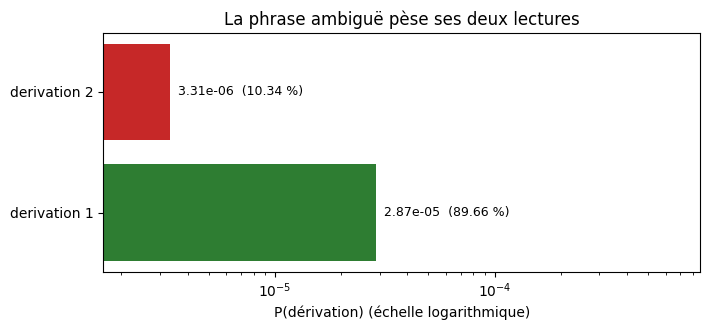

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
labels = [f"derivation {r}" for r in df_amb["rang"]]
valeurs = [float(x) for x in df_amb["P(derivation)"]]
ax.barh(labels, valeurs, color=["#2e7d32", "#c62828"])
ax.set_xscale("log")
ax.set_xlabel("P(dérivation) (échelle logarithmique)")
ax.set_title("La phrase ambiguë pèse ses deux lectures")
for j, (v, part) in enumerate(zip(valeurs, df_amb["part de P(phrase)"])):
    ax.text(v, j, f"  {v:.2e}  ({part})", va="center", fontsize=9)
ax.set_xlim(valeurs[-1] * 0.5, max(valeurs) * 30)
plt.tight_layout()
plt.show()
plt.close("all")


### Lecture du resultat

Le bar chart montre les deux masses de probabilite separees par presque un ordre de grandeur (echelle log). C'est une phrase **faiblement ambigue** pour cette PCFG : la masse se concentre a ~90 % sur une lecture. Sur une grammaire reelle, l'ambiguite croit fortement avec la taille du lexique et des regles : les lectures rivales s'y multiplient bien au-dela de nos deux cas — ce qui justifie l'existence meme des PCFG : sans probabilites, un parseur ne saurait pas *trancher*.

La cellule suivante montre la derivation Viterbi en figure : c'est la reponse que le parseur « propose » a l'utilisateur.


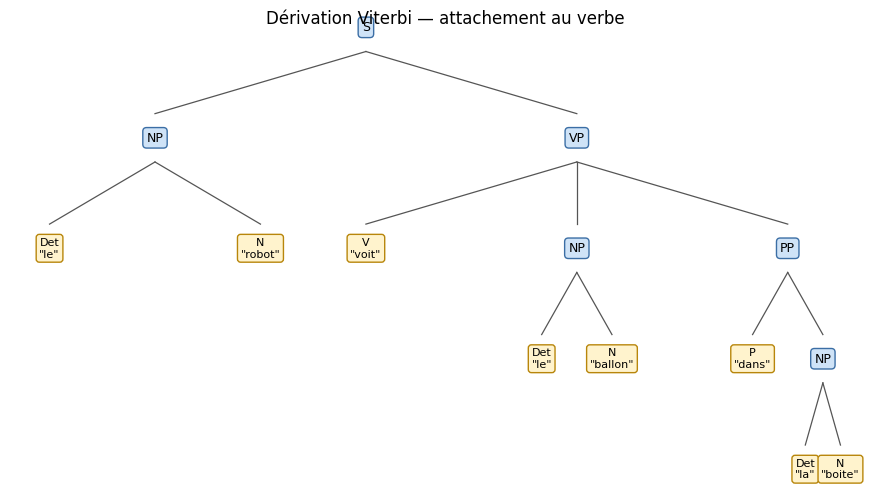

In [13]:
def dessine_arbre(ax, noeud, x, y, dx, dy):
    """Dessin recursif : noeud interne = rectangle, feuille = texte."""
    if noeud["mot"] is not None:
        ax.text(x, y, f'{noeud["sym"]}\n"{noeud["mot"]}"', ha="center", va="center",
                fontsize=8, bbox=dict(boxstyle="round,pad=0.28", facecolor="#fff3cd",
                                      edgecolor="#b8860b"))
        return
    ax.text(x, y, noeud["sym"], ha="center", va="center", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#cfe3f7", edgecolor="#3b6ea5"))
    k = len(noeud["enfants"])
    for j, e in enumerate(noeud["enfants"]):
        xe = x + (j - (k - 1) / 2) * dx
        ye = y - dy
        ax.plot([x, xe], [y - 0.035, ye + 0.035], color="#555555", lw=0.9)
        dessine_arbre(ax, e, xe, ye, dx / max(k, 1.15), dy)

fig, ax = plt.subplots(figsize=(9, 5))
dessine_arbre(ax, arbre_viterbi, 0.5, 1.0, 0.34, 0.16)
ax.axis("off")
ax.set_title("Dérivation Viterbi — attachement au verbe")
plt.tight_layout()
plt.show()
plt.close("all")


### Lecture du resultat

L'arbre dessine confirme visuellement la lecture dominante : `PP (P dans, NP la boite)` est le **troisieme enfant de VP**, pas un complement du nom `ballon`. La figure est le format de sortie canonique d'un parseur : tout systeme TAL qui analyse une phrase produit une telle structure, que ce soit par PCFG, par transition-based parsing ou par un LLM structure.


## 7. Témoin NLTK : verifier notre parseur contre la reference

Une implementation from scratch n'est credible que si elle **coincide** avec l'outil de reference. NLTK fournit exactement nos trois algorithmes : `ChartParser` (toutes les analyses), `ViterbiParser` (la meilleure), `InsideChartParser` (toutes les analyses ponderees). On lui donne la **meme** PCFG — construite production par production depuis nos probabilites MLE — et les **memes** phrases, puis on compare chiffre a chiffre, avec des assertions d'egalite (tolerance flottante 1e-9 relative).

Ce témoin fait deux choses : il valide notre code (toute divergence invaliderait une hypothese), et il **ancre** ce notebook dans l'ecosysteme reel — NLTK est la bibliotheque de reference du TAL pedagogique.


In [14]:
from nltk.grammar import PCFG, Nonterminal, ProbabilisticProduction
from nltk.parse import ChartParser, InsideChartParser, ViterbiParser

def pcfg_nltk(probas):
    """Construit la nltk.PCFG de la grammaire PONDÉRÉE d'origine."""
    peres = {pere for pere, _ in probas}
    prods = []
    for (pere, rhs), p in probas.items():
        nrhs = tuple(Nonterminal(x) if x in peres else x for x in rhs)
        prods.append(ProbabilisticProduction(Nonterminal(pere), nrhs, prob=p))
    return PCFG(Nonterminal("S"), prods)

GRAMMAIRE_NLTK = pcfg_nltk(P_FLOAT)

print("Témoin NLTK sur les mêmes phrases et la même grammaire pondérée :")
print(f"{'cas':4s} {'#parses':>8s} {'P_best nltk':>13s} {'P_best nous':>13s} "
      f"{'P_inside nltk':>14s} {'P_inside nous':>14s}")
for nom in ["P1", "P2", "AMB"]:
    jetons_t = PHRASES[nom].split()
    n_parses = len(list(ChartParser(GRAMMAIRE_NLTK).parse(jetons_t)))
    p_best_nltk = next(iter(ViterbiParser(GRAMMAIRE_NLTK).parse(jetons_t))).prob()
    p_inside_nltk = sum(t.prob() for t in InsideChartParser(GRAMMAIRE_NLTK).parse(jetons_t))
    best_t, inside_t, back_t, _ = viterbi_inside(CNF_PONDEREE, P_CNF, PHRASES[nom])
    p_best_ours = best_t[0][len(jetons_t)].get("S", 0.0)
    p_inside_ours = inside_t[0][len(jetons_t)].get("S", 0.0)
    assert math.isclose(p_best_nltk, p_best_ours, rel_tol=1e-9), nom
    assert math.isclose(p_inside_nltk, p_inside_ours, rel_tol=1e-9), nom
    print(f"{nom:4s} {n_parses:8d} {p_best_nltk:13.6e} {p_best_ours:13.6e} "
          f"{p_inside_nltk:14.6e} {p_inside_ours:14.6e}")
print("\nConcordance exacte (best et inside) entre notre implémentation et NLTK")

# nltk : l'arbre Viterbi sur la phrase ambiguë
arbre_nltk = next(iter(ViterbiParser(GRAMMAIRE_NLTK).parse(jetons_amb)))
print("\nArbre Viterbi selon NLTK :")
print(arbre_nltk.pformat())

# negatives chez nltk : mot hors lexique -> exception documentee
try:
    list(ChartParser(GRAMMAIRE_NLTK).parse(PHRASES["N2"].split()))
except ValueError as err:
    print(f"\nNLTK sur N2 : ValueError -> {err}")


Témoin NLTK sur les mêmes phrases et la même grammaire pondérée :
cas   #parses   P_best nltk   P_best nous  P_inside nltk  P_inside nous
P1          1  5.922012e-03  5.922012e-03   5.922012e-03   5.922012e-03
P2          1  4.545101e-03  4.545101e-03   4.545101e-03   4.545101e-03
AMB         2  2.871055e-05  2.871055e-05   3.202330e-05   3.202330e-05

Concordance exacte (best et inside) entre notre implémentation et NLTK

Arbre Viterbi selon NLTK :
(S
  (NP (Det le) (N robot))
  (VP
    (V voit)
    (NP (Det le) (N ballon))
    (PP (P dans) (NP (Det la) (N boite)))))

NLTK sur N2 : ValueError -> Grammar does not cover some of the input words: "'zorglub'".


### Lecture du resultat

La concordance est **exacte** sur les trois phrases positives/ambigues et les deux quantites :

| Cas | #parses NLTK | P_best NLTK | P_best (nous) | P_inside NLTK | P_inside (nous) |
|---|---|---|---|---|---|
| P1 | 1 | 5,92e-03 | 5,92e-03 | 5,92e-03 | 5,92e-03 |
| P2 | 1 | 4,55e-03 | 4,55e-03 | 4,55e-03 | 4,55e-03 |
| AMB | **2** | 2,87e-05 | 2,87e-05 | 3,20e-05 | 3,20e-05 |

L'arbre Viterbi de NLTK, affiche en notation parenthesee, est celui de la lecture **verbale** — identique a notre reconstruction. Enfin, sur le cas negatif `N2`, NLTK leve `ValueError: Grammar does not cover some of the input words` : la ou notre table repond « non » par une cellule vide, NLTK **exige** que chaque mot soit couvert par le lexique et refuse de lancer le parsing — deux conventions d'API face a un mot inconnu.

**Point cle** : P1 et P2 ont une **seule** derivation — pour elles, Viterbi et inside coincident. C'est l'ambiguite seule qui separe les deux quantites ; le rapport de 1,12 mesure sur AMB est donc bien la *mesure d'ambiguite* annoncee.


## 8. Exercices

Trois exercices, du plus direct au plus ouvert. Chaque stub est conforme a la convention du cours : il s'execute tel quel et affiche « Exercice a completer » tant que vous n'avez pas ecrit votre solution — aucune erreur n'est provoquee volontairement.


### Exercice 1 — compter les analyses de toutes les phrases

La section 6 n'a enumere que la phrase ambigue. **Comptez** les derivations de *chaque* phrase de `PHRASES` : combien valent 0 (rejet), combien valent 1 (non ambigue), combien depassent 1 ? Completez `compte_derivations` en reutilisant `enumere_derivations`. *Indice : pour une phrase rejetee, l'enumeration retourne une liste vide — pas besoin de CYK separe.*


In [15]:
# Exercice 1 : nombre de derivations de chaque phrase du jeu de test.
def compte_derivations(phrases):
    # Etape 1 : pour chaque (nom, phrase), jeter la phrase en tokens.
    # Etape 2 : appeler enumere_derivations(CNF_PONDEREE, P_CNF, jetons, 0, n, AXIOME).
    # Etape 3 : retourner un dict {nom: nombre_de_derivations}.
    # TODO etudiant
    print("Exercice a completer")
    return None

compte_derivations(PHRASES)

Exercice a completer


### Exercice 2 — renforcer la lecture nominale

Le treebank penche pour l'attachement verbal. **Modifiez-le** : ajoutez-y l'analyse alternative de la phrase ambigue (attachement *nominal* : `le ballon dans la boite` forme un seul `NP`), puis **re-estimez** les probabilites et mesurez comment la part de la lecture nominale progresse. Un seul arbre ajoute reduit l'avantage verbal d'un facteur 8,7 a 3,75 sans le renverser : combien d'exemples nominaux faudrait-il pour inverser la lecture dominante ? Completez `treebank_etendu` et `part_verbale`. *Indice : l'arbre a ajouter est `(S (NP (Det le) (N robot)) (VP (V voit) (NP (Det le) (N ballon) (PP (P dans) (NP (Det la) (N boite))))))` ; il suffit ensuite de rejouer les comptages de la section 4.*


In [16]:
# Exercice 2 : ajouter l'attachement nominal au treebank et re-mesurer.
ARBRE_NOMINAL = ("(S (NP (Det le) (N robot)) "
                 "(VP (V voit) (NP (Det le) (N ballon) "
                 "(PP (P dans) (NP (Det la) (N boite))))))")

def treebank_etendu():
    # Etape 1 : construire TREEBANK + [ARBRE_NOMINAL].
    # Etape 2 : re-compter les regles et re-estimer les probabilites MLE.
    # Etape 3 : retourner le nouveau dict de probabilites.
    # TODO etudiant
    print("Exercice a completer")
    return None

def part_verbale(probas):
    # Etape 1 : convertir la grammaire ponderee en CNF (vers_cnf avec probas).
    # Etape 2 : enumerer les derivations de la phrase ambigue.
    # Etape 3 : retourner la part de P(phrase) portee par la lecture verbale.
    # TODO etudiant
    print("Exercice a completer")
    return None

treebank_etendu()
part_verbale(None)

Exercice a completer
Exercice a completer


### Exercice 3 — le lissage qui sauve les mots inconnus

Le MLE nu donne `P(Det -> une) = 0` : toute phrase avec « une » est condamnee. Implementez le **lissage add-one** : ajoutez 1 a chaque compte de regle avant de normaliser, puis verifiez que « une robot voit le ballon » (ungrammatical mais *parseable*) obtient desormais une probabilite **non nulle**. Completez `mle_lisse` et `proba_phrase`. *Indice : la somme des comptes augmentee doit rester une distribution ; `P(phrase)` se lit dans la table inside apres conversion CNF.*


In [17]:
# Exercice 3 : lissage add-one des probabilites MLE.
def mle_lisse(comptes, alpha=1):
    # Etape 1 : pour chaque regle, compte + alpha.
    # Etape 2 : re-normaliser par pere (le total par pere augmente de alpha * nb_regles_du_pere).
    # Etape 3 : retourner le dict de probabilites lissees.
    # TODO etudiant
    print("Exercice a completer")
    return None

def proba_phrase(probas, phrase):
    # Etape 1 : convertir en CNF ponderee (vers_cnf avec probas).
    # Etape 2 : viterbi_inside sur la phrase.
    # Etape 3 : retourner inside[0][n].get(AXIOME, 0.0).
    # TODO etudiant
    print("Exercice a completer")
    return None

mle_lisse(comptes)
proba_phrase(None, "une robot voit le ballon")

Exercice a completer
Exercice a completer


## Conclusion

Ce notebook a construit, mesure et verifie une chaine complete de parsing probabiliste sur un mini-francais fil rouge :

- une **CFG explicite** (7 regles syntaxiques, 18 lexicales) et sa conversion **CNF** documentee — 31 regles, propriete formelle verifiee, distribution **preservee** a 1,000000 par non-terminal ;
- le **recognizer CYK** from scratch en table triangulaire, avec verdicts positifs, negatifs *expliques par la table* (echec structurel vs lexical), et visualisation cellule par cellule de la phrase ambigue ;
- une **PCFG estimee par MLE** sur un mini-treebank de 6 arbres embarques, avec le biais d'attachement mesure (verbal 0,33 vs nominal 0,07) et le defaut du MLE nu exhibe (`Det -> une` a 0) ;
- le decodage **Viterbi + backpointers** : meilleure derivation 2,87e-05, arbre reconstruit dans la grammaire d'origine, coherence produit-direct/Viterbi exacte ;
- l'**ambiguite mesuree** : 2 derivations, 89,7 % / 10,3 %, et la distinction P(meilleure) ≠ P(phrase) = 3,20e-05 demontree par l'egalite inside = somme des derivations ;
- le **temoin NLTK** : concordance exacte sur #parses, P_best et P_inside pour les trois cas, et comportement contrasté sur le mot inconnu (exception vs cellule vide).

**Points cles a retenir** :

1. La **CNF** est une representation exacte, pas une approximation : elle existe pour rendre la recurrence a deux coupures (et donc la complexite cubique) possible ;
2. **Viterbi** repond « quelle analyse ? », **inside** repond « quelle vraisemblance ? » — deux questions differentes, deux operateurs (`max` vs somme) dans la meme table ;
3. Les probabilites d'une PCFG **sont** le treebank : changer un arbre dans le corpus d'apprentissage deplace la lecture dominante (exercice 2) ;
4. Un parseur from scratch se **verifie** contre un temoin de reference ; l'egalite a 1e-9 est le critere.

**Ponts** : [`23_TAL_Du_Mot_Aux_Dependances.ipynb`](23_TAL_Du_Mot_Aux_Dependances.ipynb) pour l'etage mot/dependances que cette grammaire sous-tend ; la serie `Search` pour la programmation dynamique qui est le moteur de CYK ; [`RAG-et-Memoire-Semantique/04-Tokenisation-From-Scratch.ipynb`](../RAG-et-Memoire-Semantique/04-Tokenisation-From-Scratch.ipynb) pour la frontiere entre analyse symbolique (ici) et encodage sous-mot des LLM. Pour aller plus loin : l'**algorithme Earley** (leve la contrainte CNF), le **PCFG lexicalise** (Collins), et les parseurs a transitions qui ont succede aux PCFG en production.
